In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/content/cancer-risk-factors.csv')

In [5]:
df.head()

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [7]:
df.columns

Index(['Patient_ID', 'Cancer_Type', 'Age', 'Gender', 'Smoking', 'Alcohol_Use',
       'Obesity', 'Family_History', 'Diet_Red_Meat', 'Diet_Salted_Processed',
       'Fruit_Veg_Intake', 'Physical_Activity', 'Air_Pollution',
       'Occupational_Hazards', 'BRCA_Mutation', 'H_Pylori_Infection',
       'Calcium_Intake', 'Overall_Risk_Score', 'BMI',
       'Physical_Activity_Level', 'Risk_Level'],
      dtype='object')

## identification

- patient id - unique id for each patient
- cancer type - the type of cancer diagnosed

## general characteristics

- age
- gENDER
- BMI

## LIFESTYLE AND ENVIRONMENTS

- smoking
- alcohol type
- family histrot
- obesity
- diet red meat
- diet salt processed
- physical activity
- air pollution

## medical factors
- family history
- BRCA mutation

## engineered
- overall rsik score
- risk level

## what to predict? : Risk level


In [9]:
df.Cancer_Type.value_counts()

,count
Cancer_Type,
Lung,527
Breast,460
Colon,418
Prostate,305
Skin,290


## understand the dataset by EDA

In [10]:
risk_counts = df['Risk_Level'].value_counts()
print(risk_counts)

Risk_Level
Medium    1574
Low        324
High       102
Name: count, dtype: int64


<Axes: xlabel='Risk_Level'>

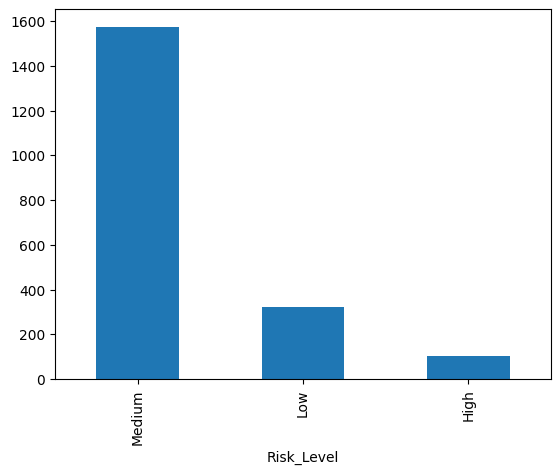

In [13]:
df['Risk_Level'].value_counts().plot(kind='bar')

In [14]:
df['Risk_Level'].value_counts()/len(df)*100

,count
Risk_Level,
Medium,78.7
Low,16.2
High,5.1


## the data is highly imbalanced
- Medium -78.7
- Low	- 16.2
- High	- 5.1

In [15]:
df.head(5)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [16]:
df.Gender.value_counts()

,count
Gender,
0,1022
1,978


<Axes: xlabel='Cancer_Type'>

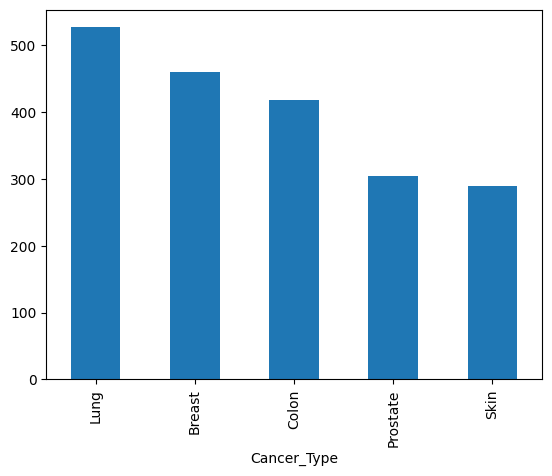

In [18]:
df.Cancer_Type.value_counts().plot(kind='bar')
# little bit imbalanced

In [19]:
gender_cancer_counts = df.groupby(['Gender', 'Cancer_Type']).size().reset_index(name= "Patient_Count")
gender_cancer_counts["Gender"] = gender_cancer_counts['Gender'].map({0: 'Female', 1: 'Male'})
print(gender_cancer_counts)

   Gender Cancer_Type  Patient_Count
0  Female      Breast            455
1  Female       Colon            197
2  Female        Lung            238
3  Female        Skin            132
4    Male      Breast              5
5    Male       Colon            221
6    Male        Lung            289
7    Male    Prostate            305
8    Male        Skin            158


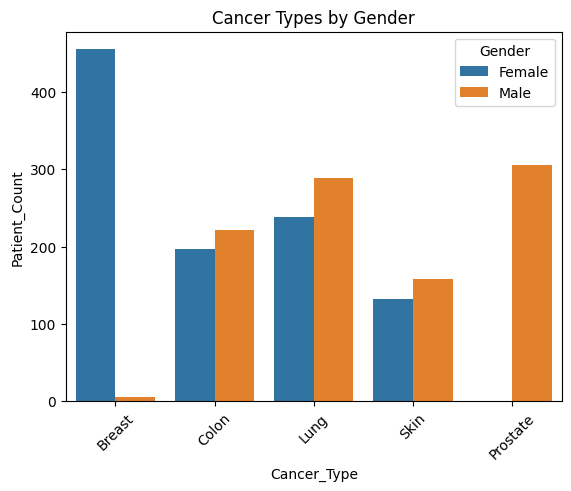

In [27]:
sns.barplot(data= gender_cancer_counts, x= 'Cancer_Type', y='Patient_Count', hue= 'Gender' )
plt.title('Cancer Types by Gender')
plt.xticks(rotation=45)
plt.show()


In [28]:
# find all  patients under 35

young_patients= df[df['Age'] < 35]
print(young_patients)

    Patient_ID Cancer_Type  Age  Gender  Smoking  Alcohol_Use  Obesity  \
420     BR0020        Skin   32       0        1            3        8   
433     BR0033        Lung   25       0        8            6        5   
454     BR0054        Lung   29       0        8            6        7   
468     BR0068        Lung   32       0        8            2        0   
495     BR0095      Breast   31       0        1            9       10   
585     BR0185        Lung   34       0        6            8        5   
593     BR0193      Breast   34       0        5            1       10   
621     BR0221        Lung   25       0        7           10        6   
698     BR0298        Lung   34       0        8            0        2   

     Family_History  Diet_Red_Meat  Diet_Salted_Processed  ...  \
420               0              5                      1  ...   
433               0              3                      5  ...   
454               0              3                      0  ..

In [30]:
count_young = (df['Age'] < 35).sum()
print(f"Number pf patients under 35: {count_young}")



Number pf patients under 35: 9


In [31]:
young_cancer_types= df[df['Age'] < 35]['Cancer_Type'].value_counts()
print(young_cancer_types)

Cancer_Type
Lung      6
Breast    2
Skin      1
Name: count, dtype: int64


this shoes which cnacer types appears among young patients and how many cases of each

In [32]:
## finding out which factor highly contribute to high risk level

# select only th enumerical columns

numeric_columns = df.select_dtypes(include='number').columns

#Compute the mean of each number feature per risk level
risk_means = df.groupby('Risk_Level')[numeric_columns].mean().T
print(risk_means)

Risk_Level                    High        Low     Medium
Age                      63.745098  63.685185  63.125794
Gender                    0.509804   0.493827   0.486658
Smoking                   7.519608   2.845679   5.479670
Alcohol_Use               7.519608   2.984568   5.296061
Obesity                   7.274510   4.824074   6.118170
Family_History            0.205882   0.138889   0.205210
Diet_Red_Meat             7.362745   3.972222   5.299238
Diet_Salted_Processed     7.039216   2.888889   4.747776
Fruit_Veg_Intake          3.911765   5.666667   4.841169
Physical_Activity         4.921569   3.669753   4.027319
Air_Pollution             8.539216   2.947531   5.603558
Occupational_Hazards      6.990196   3.364198   5.181067
BRCA_Mutation             0.049020   0.037037   0.030496
H_Pylori_Infection        0.245098   0.175926   0.197586
Calcium_Intake            4.323529   3.651235   3.975222
Overall_Risk_Score        0.699991   0.269458   0.476616
BMI                      26.225

## Insights
- heavy smokers
- high alcohol
- high red meat
- high intake of salt
- exposure to high air pollution
- Higher Obesity
- Jobs with HAzardous

In [34]:
#Focus on diff btw high and low risk

risk_diff = risk_means['High'] - risk_means['Low']
risk_diff = risk_diff.sort_values(ascending= False)
print(risk_diff)

Air_Pollution              5.591685
Smoking                    4.673929
Alcohol_Use                4.535040
Diet_Salted_Processed      4.150327
Occupational_Hazards       3.625999
Diet_Red_Meat              3.390523
Obesity                    2.450436
Physical_Activity          1.251816
Calcium_Intake             0.672295
Overall_Risk_Score         0.430533
BMI                        0.410984
Physical_Activity_Level    0.337509
H_Pylori_Infection         0.069172
Family_History             0.066993
Age                        0.059913
Gender                     0.015977
BRCA_Mutation              0.011983
Fruit_Veg_Intake          -1.754902
dtype: float64


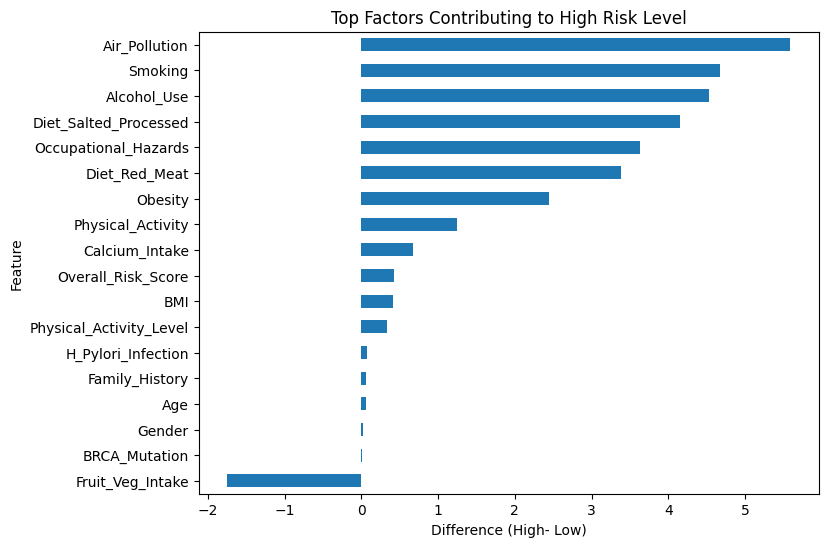

In [38]:
risk_diff.sort_values(ascending= True).plot(kind='barh', figsize=(8,6), title='Top Factors Contributing to High Risk Level')
plt.xlabel('Difference (High - Low)')
plt.ylabel('Feature')
plt.show()

## Air Pollution, smoking m alcohol use are top 3  contibuting factor in high risk level

In [39]:
bmi_by_risk = df.groupby('Risk_Level')['BMI'].mean()
print(bmi_by_risk)

Risk_Level
High      26.225490
Low       25.814506
Medium    26.256544
Name: BMI, dtype: float64


##Univariate Analysis

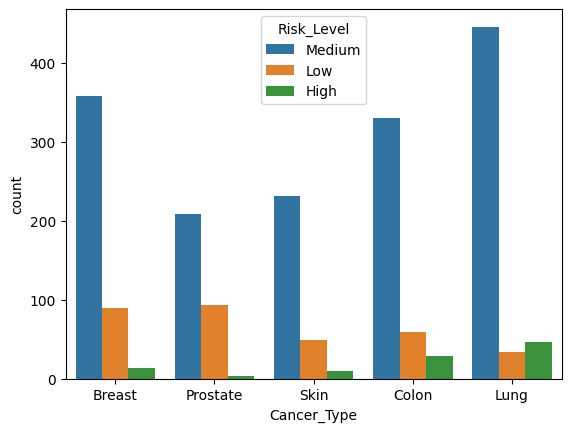

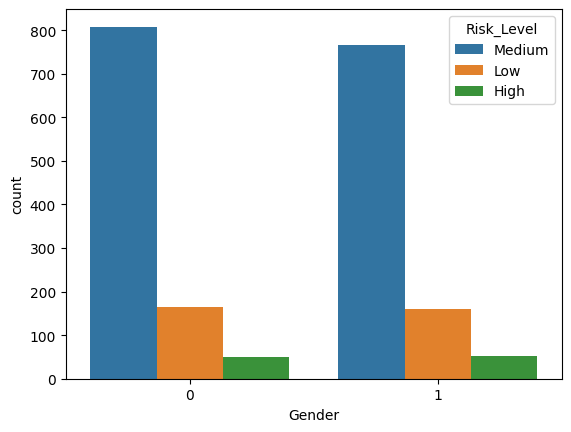

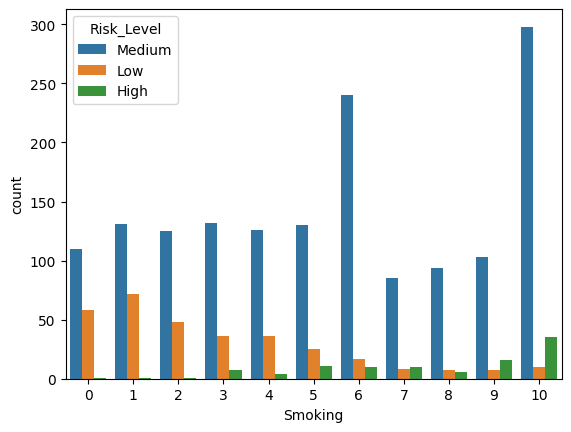

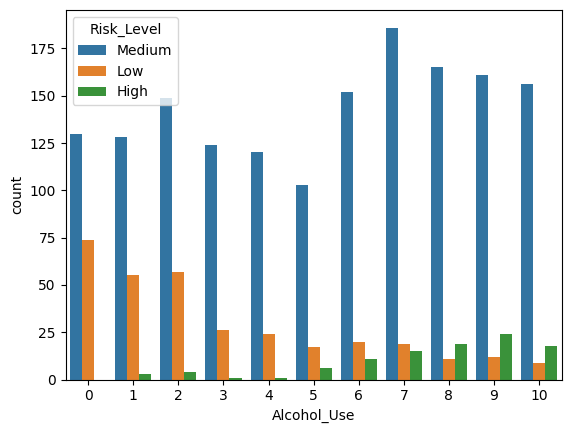

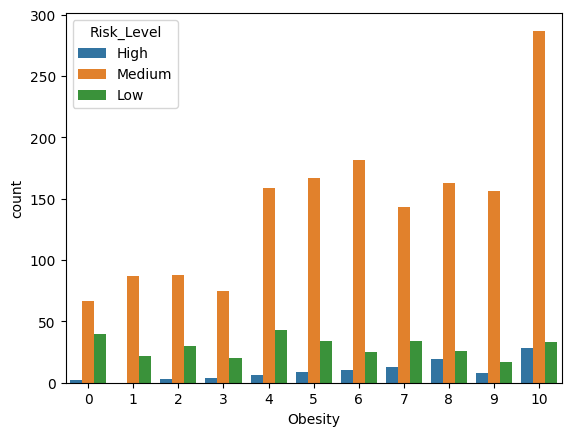

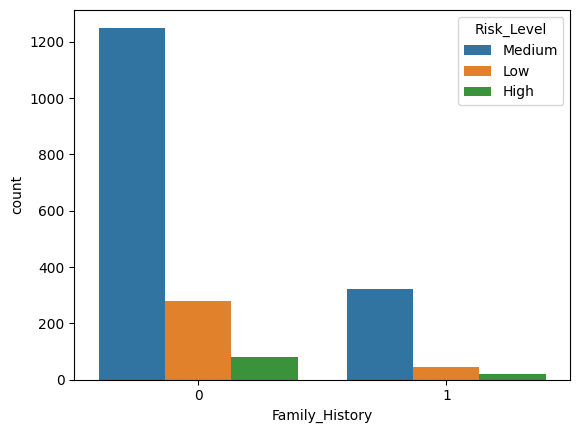

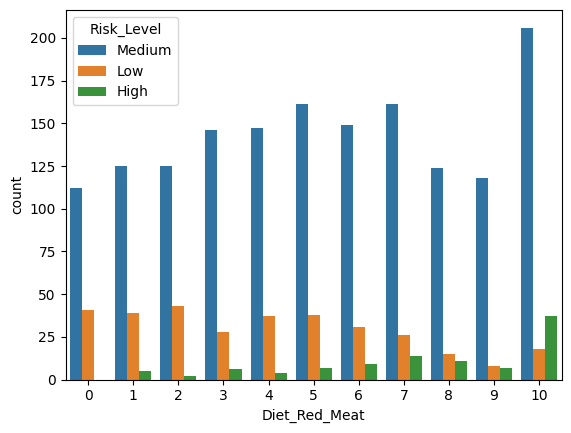

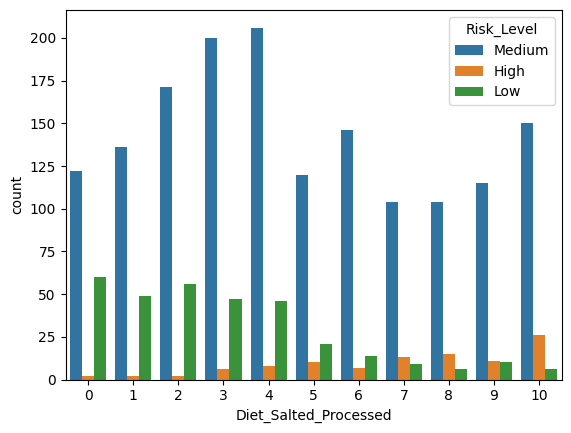

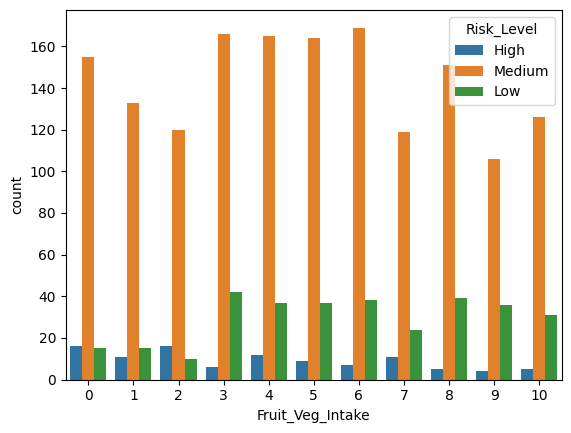

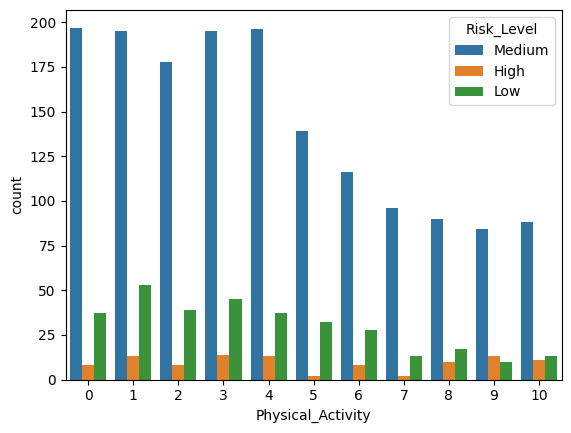

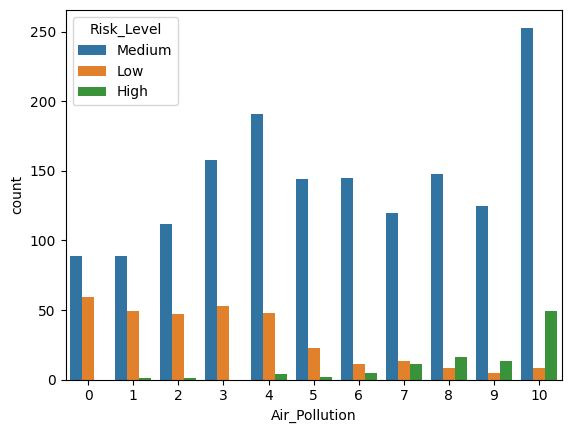

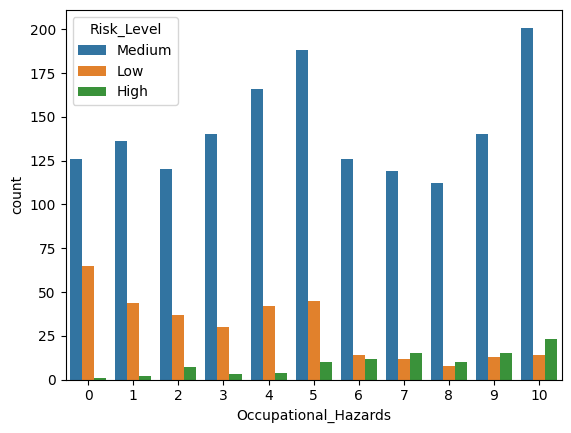

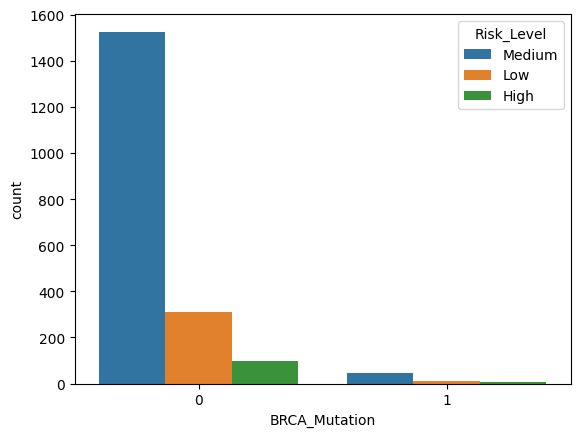

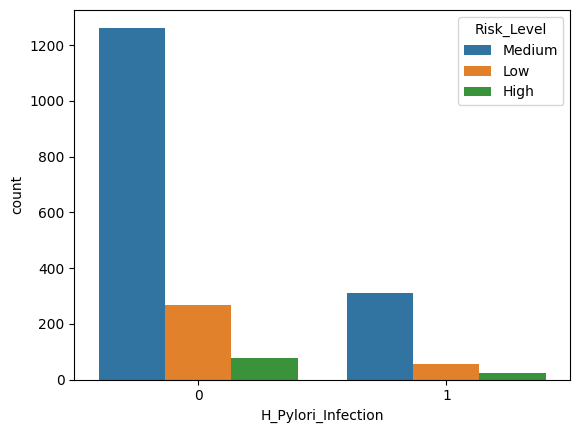

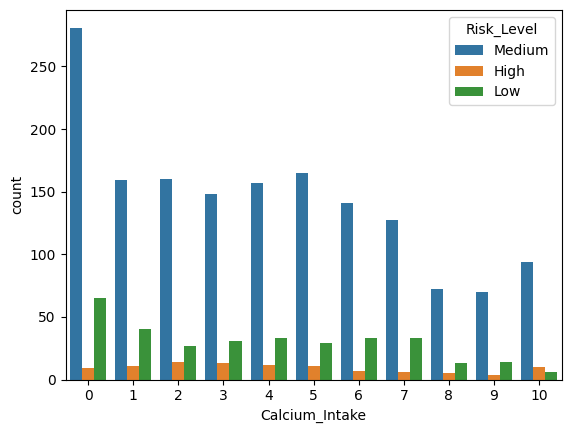

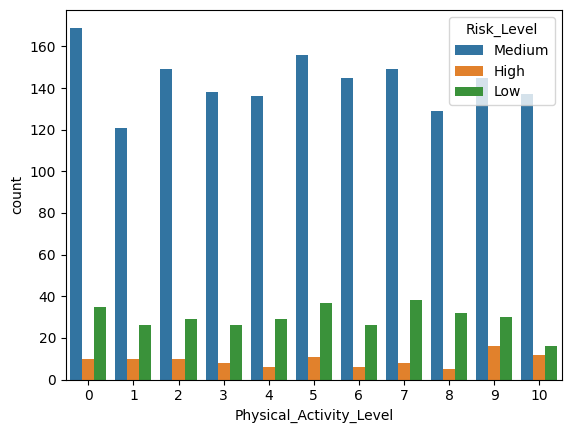

In [45]:
for i, predictor in enumerate(df.drop(columns=['Patient_ID', 'Risk_Level', 'Age', 'Overall_Risk_Score', 'BMI'])):
  plt.figure(i)
  sns.countplot(data=df, x=predictor, hue = 'Risk_Level')

## NUmerical Analysis


In [46]:
df.head(5)

,Patient_ID,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,...,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,LU0000,Breast,68,0,7,2,8,0,5,3,...,4,6,3,1,0,0,0.398696,28.0,5,Medium
1,LU0001,Prostate,74,1,8,9,8,0,0,3,...,1,3,3,0,0,5,0.424299,25.4,9,Medium
2,LU0002,Skin,55,1,7,10,7,0,3,3,...,1,8,10,0,0,6,0.605082,28.6,2,Medium
3,LU0003,Colon,61,0,6,2,2,0,6,2,...,6,4,8,0,0,8,0.318449,32.1,7,Low
4,LU0004,Lung,67,1,10,7,4,0,6,3,...,9,10,9,0,0,5,0.524358,25.1,2,Medium


In [48]:
df= df.drop(columns=['Patient_ID'])


In [50]:
df['Risk_Level'] = df['Risk_Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

In [51]:
df.head(5)

,Cancer_Type,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,Air_Pollution,Occupational_Hazards,BRCA_Mutation,H_Pylori_Infection,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level
0,Breast,68,0,7,2,8,0,5,3,7,4,6,3,1,0,0,0.398696,28.0,5,NaN
1,Prostate,74,1,8,9,8,0,0,3,7,1,3,3,0,0,5,0.424299,25.4,9,NaN
2,Skin,55,1,7,10,7,0,3,3,4,1,8,10,0,0,6,0.605082,28.6,2,NaN
3,Colon,61,0,6,2,2,0,6,2,4,6,4,8,0,0,8,0.318449,32.1,7,NaN
4,Lung,67,1,10,7,4,0,6,3,10,9,10,9,0,0,5,0.524358,25.1,2,NaN


In [53]:
df_dummies = pd.get_dummies(df)
df_dummies.head(5)

,Age,Gender,Smoking,Alcohol_Use,Obesity,Family_History,Diet_Red_Meat,Diet_Salted_Processed,Fruit_Veg_Intake,Physical_Activity,...,Calcium_Intake,Overall_Risk_Score,BMI,Physical_Activity_Level,Risk_Level,Cancer_Type_Breast,Cancer_Type_Colon,Cancer_Type_Lung,Cancer_Type_Prostate,Cancer_Type_Skin
0,68,0,7,2,8,0,5,3,7,4,...,0,0.398696,28.0,5,NaN,True,False,False,False,False
1,74,1,8,9,8,0,0,3,7,1,...,5,0.424299,25.4,9,NaN,False,False,False,True,False
2,55,1,7,10,7,0,3,3,4,1,...,6,0.605082,28.6,2,NaN,False,False,False,False,True
3,61,0,6,2,2,0,6,2,4,6,...,8,0.318449,32.1,7,NaN,False,True,False,False,False
4,67,1,10,7,4,0,6,3,10,9,...,5,0.524358,25.1,2,NaN,False,False,True,False,False


<Axes: >

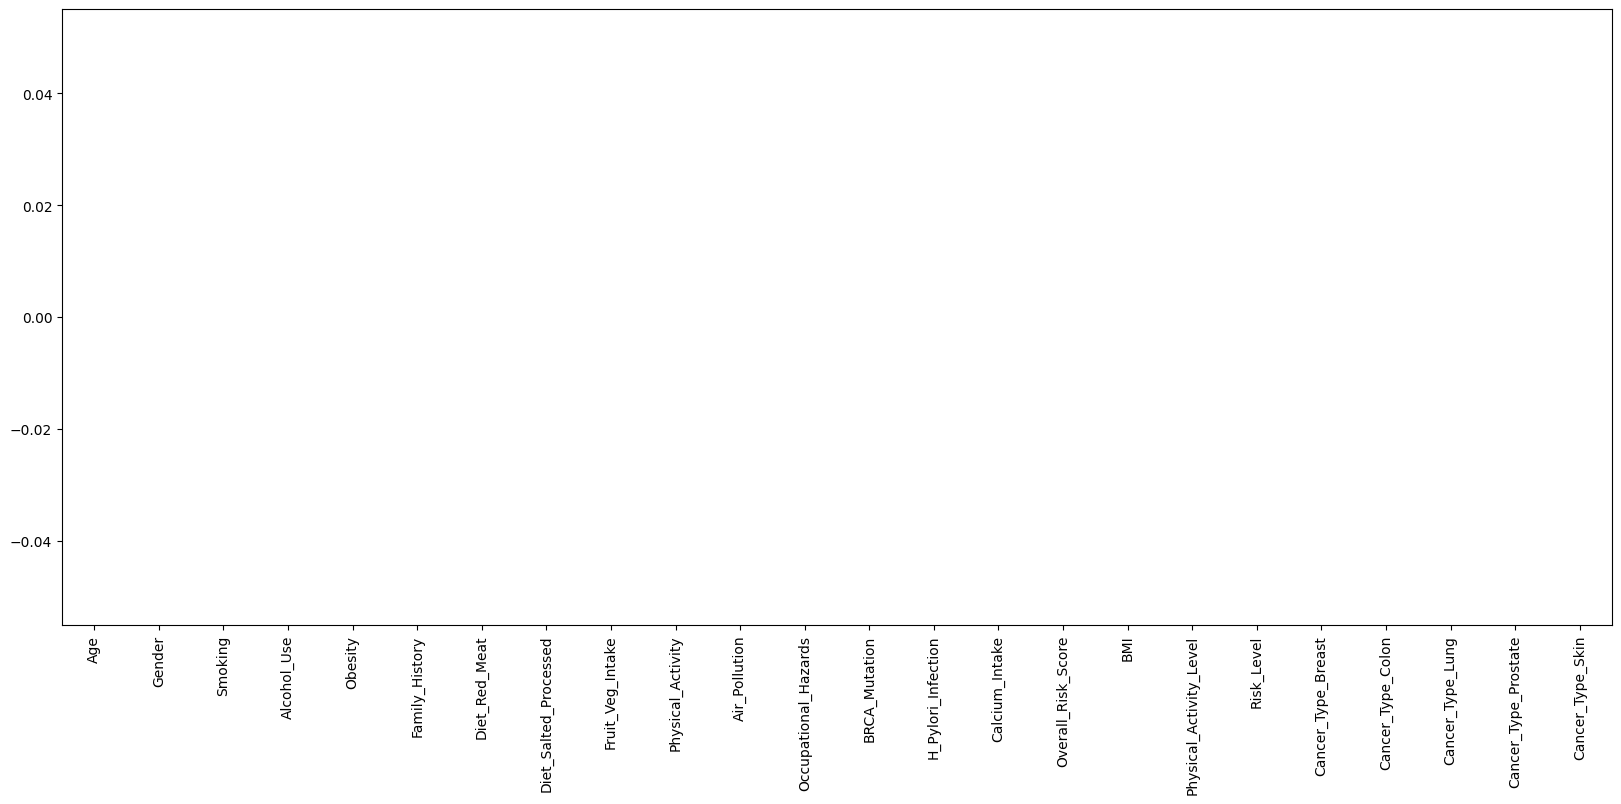

In [56]:
plt.figure(figsize=(20,8))
df_dummies.corr()['Risk_Level'].sort_values(ascending= False).plot(kind='bar')






## Model Building